# 02 · Filtrado fino y split público / privado

Este notebook toma la salida del **01_preprocesamiento_denue.ipynb** (`salud_cdmx_denue_limpio.csv`) y la refina para el análisis topológico:

1. **Filtro SCIAN más estricto** — solo infraestructura médica real (consultorios, hospitales, laboratorios, centros ambulatorios). Se excluyen residencias para adultos mayores, agrupaciones de autoayuda (AA), guarderías y comunidades terapéuticas.
2. **Split público vs privado** — usando *string matching* sobre `nombre_act`.
3. **Reproyección a UTM 14N (EPSG:32614)** — para que las distancias queden en metros y los radios del Vietoris-Rips sean interpretables ("este hueco tiene 800 m de radio ≈ 10 min caminando").
4. **Manejo de duplicados** — jitter de ±5 m a puntos con coordenadas idénticas (típico de plazas médicas con varios consultorios en la misma dirección).
5. **Outliers geográficos** — recorte al bounding box de CDMX.

**Salidas:**
- `../data/processed/salud_cdmx_publico.csv` — nube de puntos del sector público
- `../data/processed/salud_cdmx_privado.csv` — nube de puntos del sector privado

In [1]:
pip install geopandas pyproj

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# geopandas es la única dependencia nueva. Si no la tienen:
#   pip install geopandas pyproj
import geopandas as gpd

# Semilla para reproducibilidad del jitter
RNG = np.random.default_rng(42)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Cargar el CSV procesado del notebook 01

In [3]:
import urllib.request
import zipfile

# Rutas
DATA_RAW_DIR = "../data/raw"
DATA_PROC_DIR = "../data/processed"
ZIP_PATH = os.path.join(DATA_RAW_DIR, "denue_09_csv.zip")
PROCESSED_CSV = os.path.join(DATA_PROC_DIR, "salud_cdmx_denue_limpio.csv")

# URL del zip (SAS token válido hasta el 9 de junio de 2026)
DENUE_ZIP_URL = (
    "https://cfcetlsadls.blob.core.windows.net/raw/inegi/denue_por_estado/"
    "ciudad_de_mexico_zip/denue_09_csv.zip"
    "?sv=2025-07-05&spr=https&st=2026-04-24T19%3A24%3A46Z"
    "&se=2026-06-09T19%3A24%3A00Z&sr=b&sp=r"
    "&sig=%2F5%2BqqFCki1Y%2Bdl3Y21slq3HOd7Ek5cDjh849JlR37Dc%3D"
)

os.makedirs(DATA_RAW_DIR, exist_ok=True)
os.makedirs(DATA_PROC_DIR, exist_ok=True)

# 1) Descargar el zip si no existe
if not os.path.exists(ZIP_PATH):
    print("Descargando DENUE CDMX (puede tomar 1-2 min)...")
    urllib.request.urlretrieve(DENUE_ZIP_URL, ZIP_PATH)
    print(f"  -> {ZIP_PATH} ({os.path.getsize(ZIP_PATH)/1e6:.1f} MB)")
else:
    print(f"OK: zip ya existe en {ZIP_PATH}")

# 2) Regenerar el CSV procesado si no existe (replica la lógica del notebook 01)
if not os.path.exists(PROCESSED_CSV):
    print("\nRegenerando CSV procesado desde el zip (lógica del notebook 01)...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        df_raw = pd.read_csv(
            z.open("conjunto_de_datos/denue_inegi_09_.csv"),
            encoding="latin1",
            low_memory=False,
        )

    df_tmp = df_raw[df_raw["codigo_act"].astype(str).str.startswith("62")].copy()
    df_tmp["latitud"] = pd.to_numeric(df_tmp["latitud"], errors="coerce")
    df_tmp["longitud"] = pd.to_numeric(df_tmp["longitud"], errors="coerce")
    df_tmp = df_tmp.dropna(subset=["latitud", "longitud"])

    cols = ["id", "nom_estab", "codigo_act", "nombre_act", "per_ocu",
            "municipio", "localidad", "latitud", "longitud", "fecha_alta"]
    df_tmp[cols].to_csv(PROCESSED_CSV, index=False)
    print(f"  -> {PROCESSED_CSV} ({len(df_tmp):,} filas)")
else:
    print(f"OK: CSV procesado ya existe en {PROCESSED_CSV}")

OK: zip ya existe en ../data/raw/denue_09_csv.zip
OK: CSV procesado ya existe en ../data/processed/salud_cdmx_denue_limpio.csv


In [4]:
# revisar contenidos del zip

zip_path = "../data/raw/denue_09_csv.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    archivos = z.namelist()
    print(archivos)

['diccionario_de_datos/denue_diccionario_de_datos.csv', 'conjunto_de_datos/denue_inegi_09_.csv', 'metadatos/metadatos_denue.txt']


In [5]:
df = pd.read_csv("../data/processed/salud_cdmx_denue_limpio.csv")
print(f"Establecimientos del sector salud (62 completo): {len(df):,}")
df.head()

Establecimientos del sector salud (62 completo): 22,841


,id,nom_estab,codigo_act,nombre_act,per_ocu,municipio,localidad,latitud,longitud,fecha_alta
0,11822253,MARIE STOPES CONDESA,621411,Centros de planificación familiar del sector p...,11 a 30 personas,Cuauhtémoc,Cuauhtémoc ...,19.415518,-99.172861,2025-04
1,6795800,113 LABORATORIO MEDICO DEL CHOPO SUCURSAL ARENAL,621511,Laboratorios médicos y de diagnóstico del sect...,0 a 5 personas,Xochimilco,Xochimilco ...,19.280340,-99.137950,2017-03
2,8485187,19 DISTRITO DE SERVICIOS GENERALES ALCOHOLICOS...,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,Cuauhtémoc,Cuauhtémoc ...,19.460542,-99.131678,2019-11
3,767683,1ER DISTRITO AREA NORTE DE ALCOHOLICOS ANONIMOS,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,Gustavo A. Madero,Gustavo A. Madero ...,19.492214,-99.087259,2010-07
4,11366041,20 DENTAL,621211,Consultorios dentales del sector privado,0 a 5 personas,Venustiano Carranza,Venustiano Carranza ...,19.440626,-99.107722,2024-11


## Paso 1 · Filtro SCIAN estricto

El sector 62 incluye actividades muy heterogéneas. Para análisis topológico de **cobertura médica** nos quedamos solo con infraestructura clínica real:

| Sub-rama | Códigos | Qué incluye |
|---|---|---|
| Consultorios | `6211**` | Medicina general, especializada, dental, optometría, etc. |
| Centros ambulatorios | `6214**` | Planificación familiar, atención sin hospitalización |
| Laboratorios y diagnóstico | `6215**` | Laboratorios clínicos, imagenología |
| Hospitales | `6221**`, `6222**`, `6223**` | Generales, psiquiátricos, otras especialidades |

**Se excluyen:** `6231–6239` (residencias para adultos mayores y con discapacidad), `6241–6244` (asistencia social, AA, comedores comunitarios, guarderías). Estas categorías no son "atención médica" en el sentido del análisis.

In [6]:
# Verificar qué prefijos de 4 dígitos tenemos
df["codigo_4d"] = df["codigo_act"].astype(str).str[:4]
print("Distribución por prefijo de 4 dígitos:")
print(df["codigo_4d"].value_counts().sort_index())

Distribución por prefijo de 4 dígitos:
codigo_4d
6211    6638
6212    7334
6213    4025
6214     141
6215     797
6216       8
6219      23
6221     257
6222      14
6223     102
6231      16
6232      79
6233     109
6239     124
6241    2089
6242     482
6243      22
6244     581
Name: count, dtype: int64


In [7]:
# Aplicar filtro estricto
prefijos_validos = ["6211", "6214", "6215", "6221", "6222", "6223"]

df_estricto = df[df["codigo_4d"].isin(prefijos_validos)].copy()

print(f"Antes (sector 62 completo): {len(df):,}")
print(f"Después (infraestructura médica real): {len(df_estricto):,}")
print(f"Reducción: {len(df) - len(df_estricto):,} establecimientos eliminados\n")

# Agregar etiqueta de tipo de infraestructura (útil para análisis posterior)
mapa_tipo = {
    "6211": "Consultorio",
    "6214": "Centro ambulatorio",
    "6215": "Laboratorio/Dx",
    "6221": "Hospital general",
    "6222": "Hospital psiquiátrico",
    "6223": "Hospital especializado",
}
df_estricto["tipo_infra"] = df_estricto["codigo_4d"].map(mapa_tipo)

print("Composición de la nube médica:")
print(df_estricto["tipo_infra"].value_counts())

Antes (sector 62 completo): 22,841
Después (infraestructura médica real): 7,949
Reducción: 14,892 establecimientos eliminados

Composición de la nube médica:
tipo_infra
Consultorio               6638
Laboratorio/Dx             797
Hospital general           257
Centro ambulatorio         141
Hospital especializado     102
Hospital psiquiátrico       14
Name: count, dtype: int64


## Paso 2 · Split público vs privado

El SCIAN 2018 codifica la distinción en el **texto** de `nombre_act` (no en los dígitos de forma uniforme), así que hacemos string matching sobre frases canónicas: *"sector público"* y *"sector privado"*.

Los establecimientos que no caigan en ninguna categoría (por estar mal capturados o por ser sectores mixtos) los marcamos como `otro` y los revisamos antes de descartar.

In [8]:
# Normalizar texto a minúsculas para evitar problemas de acentos/mayúsculas
nombre_lower = df_estricto["nombre_act"].str.lower().fillna("")

es_publico = nombre_lower.str.contains("sector público")
es_privado = nombre_lower.str.contains("sector privado")

df_estricto["sector"] = np.select(
    [es_publico, es_privado],
    ["publico", "privado"],
    default="otro"
)

print("Distribución por sector:")
print(df_estricto["sector"].value_counts())
print()
print("Proporción:")
print((df_estricto["sector"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Distribución por sector:
sector
privado    7365
publico     584
Name: count, dtype: int64

Proporción:
sector
privado    92.65 %
publico     7.35 %
Name: proportion, dtype: object


In [9]:
# ¿Qué actividades quedaron en "otro"? Revisar antes de descartar
otros = df_estricto[df_estricto["sector"] == "otro"]
print(f"Establecimientos en categoría 'otro': {len(otros)}")
if len(otros) > 0:
    print("\nActividades en 'otro':")
    print(otros["nombre_act"].value_counts().head(20))

Establecimientos en categoría 'otro': 0


In [10]:
# Decisión: descartamos "otro" porque no podemos asignarle público/privado con certeza
# Si la inspección anterior muestra que vale la pena rescatarlos, modificar esta celda
df_estricto = df_estricto[df_estricto["sector"].isin(["publico", "privado"])].copy()

print(f"Establecimientos finales (público + privado): {len(df_estricto):,}")
print(df_estricto.groupby(["sector", "tipo_infra"]).size().unstack(fill_value=0))

Establecimientos finales (público + privado): 7,949
tipo_infra  Centro ambulatorio  Consultorio  Hospital especializado  \
sector                                                                
privado                    119         6227                      80   
publico                     22          411                      22   

tipo_infra  Hospital general  Hospital psiquiátrico  Laboratorio/Dx  
sector                                                               
privado                  139                      9             791  
publico                  118                      5               6  


## Paso 3 · Reproyección a UTM 14N (EPSG:32614)

Las coordenadas en grados (lat/lon) no son métricas: 1° de latitud ≈ 111 km, pero 1° de longitud en CDMX ≈ 105 km (depende del cos(latitud)). Si calculamos distancias euclidianas sobre lat/lon, el complejo de Vietoris-Rips queda **deformado**.

Reproyectamos a UTM zona 14N — el sistema métrico estándar para el centro de México — para que las distancias estén en **metros**.

In [11]:
# Construir GeoDataFrame en WGS84 y reproyectar a UTM 14N
gdf = gpd.GeoDataFrame(
    df_estricto,
    geometry=gpd.points_from_xy(df_estricto["longitud"], df_estricto["latitud"]),
    crs="EPSG:4326"
).to_crs("EPSG:32614")

# Extraer coordenadas métricas
df_estricto["x_m"] = gdf.geometry.x.values
df_estricto["y_m"] = gdf.geometry.y.values

print("Rango en metros (UTM 14N):")
print(df_estricto[["x_m", "y_m"]].describe().round(1))
print(f"\nExtensión x: {df_estricto['x_m'].max() - df_estricto['x_m'].min():.0f} m")
print(f"Extensión y: {df_estricto['y_m'].max() - df_estricto['y_m'].min():.0f} m")

Rango en metros (UTM 14N):
            x_m        y_m
count    7949.0     7949.0
mean   483900.0  2143091.5
std      6093.6     7245.6
min    465502.1  2115977.3
25%    480543.6  2138155.6
50%    482689.2  2144507.3
75%    486762.0  2147339.1
max    505109.2  2164413.8

Extensión x: 39607 m
Extensión y: 48436 m


## Paso 4 · Duplicados de coordenadas + jitter

Es común que varios establecimientos compartan la misma (lat, lon): plazas médicas, torres de consultorios, hospitales con múltiples especialidades registrados por separado. Para TDA esto crea simplejos degenerados y artefactos en el diagrama de persistencia.

**Solución:** jitter aleatorio de ±5 m en x e y. No colapsamos los puntos porque la multiplicidad sí captura información real (densidad efectiva de servicios).

In [12]:
# Diagnóstico de duplicados antes del jitter
for s in ["publico", "privado"]:
    sub = df_estricto[df_estricto["sector"] == s]
    dups = sub.duplicated(subset=["x_m", "y_m"]).sum()
    print(f"Sector {s}: {len(sub):,} puntos, {dups:,} duplicados de coordenadas ({100*dups/len(sub):.1f} %)")

Sector publico: 584 puntos, 10 duplicados de coordenadas (1.7 %)
Sector privado: 7,365 puntos, 3,097 duplicados de coordenadas (42.1 %)


In [13]:
# Aplicar jitter gaussiano de sigma=5 metros
sigma_jitter = 5.0  # metros
df_estricto["x_m"] += RNG.normal(0, sigma_jitter, size=len(df_estricto))
df_estricto["y_m"] += RNG.normal(0, sigma_jitter, size=len(df_estricto))

# Verificar que ya no hay duplicados exactos
for s in ["publico", "privado"]:
    sub = df_estricto[df_estricto["sector"] == s]
    dups = sub.duplicated(subset=["x_m", "y_m"]).sum()
    print(f"Sector {s} tras jitter: {dups} duplicados (esperado: 0)")

Sector publico tras jitter: 0 duplicados (esperado: 0)
Sector privado tras jitter: 0 duplicados (esperado: 0)


## Paso 5 · Outliers geográficos

Recortamos al bounding box de CDMX para descartar puntos con coordenadas mal capturadas. CDMX está aproximadamente entre:

- Latitud: 19.05° — 19.60°
- Longitud: −99.40° — −98.94°

(Una versión más refinada usaría el shapefile del marco geoestadístico INEGI, pero el bounding box atrapa ya los errores gruesos.)

In [14]:
# Bounding box CDMX
LAT_MIN, LAT_MAX = 19.05, 19.60
LON_MIN, LON_MAX = -99.40, -98.94

dentro_bb = (
    (df_estricto["latitud"].between(LAT_MIN, LAT_MAX)) &
    (df_estricto["longitud"].between(LON_MIN, LON_MAX))
)

fuera = (~dentro_bb).sum()
print(f"Puntos fuera del bounding box de CDMX: {fuera}")

if fuera > 0:
    print("\nEjemplos de puntos descartados:")
    print(df_estricto[~dentro_bb][["nom_estab", "municipio", "latitud", "longitud"]].head())

df_estricto = df_estricto[dentro_bb].copy()
print(f"\nEstablecimientos finales tras todo el preprocesamiento: {len(df_estricto):,}")

Puntos fuera del bounding box de CDMX: 0

Establecimientos finales tras todo el preprocesamiento: 7,949


## Visualización: público vs privado lado a lado

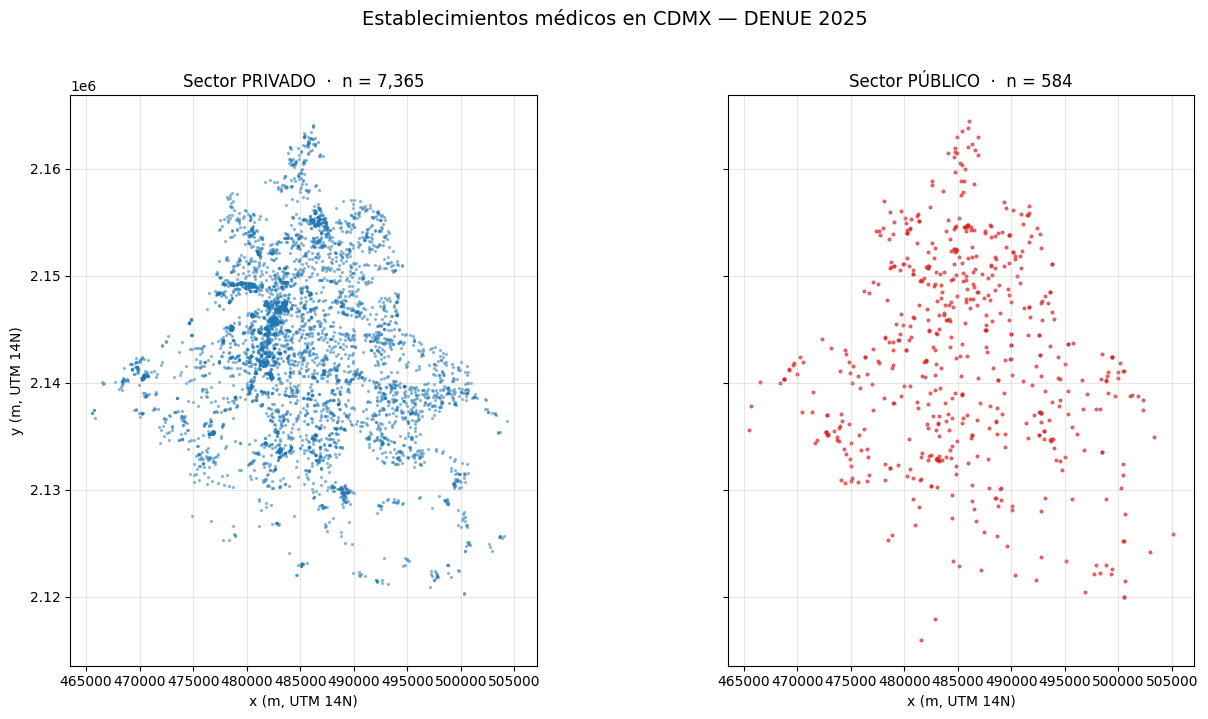

In [15]:
df_pub = df_estricto[df_estricto["sector"] == "publico"].copy()
df_priv = df_estricto[df_estricto["sector"] == "privado"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

# Panel 1: Privado
axes[0].scatter(df_priv["x_m"], df_priv["y_m"], s=2, alpha=0.4, color="#1f77b4")
axes[0].set_title(f"Sector PRIVADO  ·  n = {len(df_priv):,}")
axes[0].set_xlabel("x (m, UTM 14N)")
axes[0].set_ylabel("y (m, UTM 14N)")
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.3)

# Panel 2: Público
axes[1].scatter(df_pub["x_m"], df_pub["y_m"], s=4, alpha=0.6, color="#d62728")
axes[1].set_title(f"Sector PÚBLICO  ·  n = {len(df_pub):,}")
axes[1].set_xlabel("x (m, UTM 14N)")
axes[1].set_aspect("equal")
axes[1].grid(alpha=0.3)

plt.suptitle("Establecimientos médicos en CDMX — DENUE 2025", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

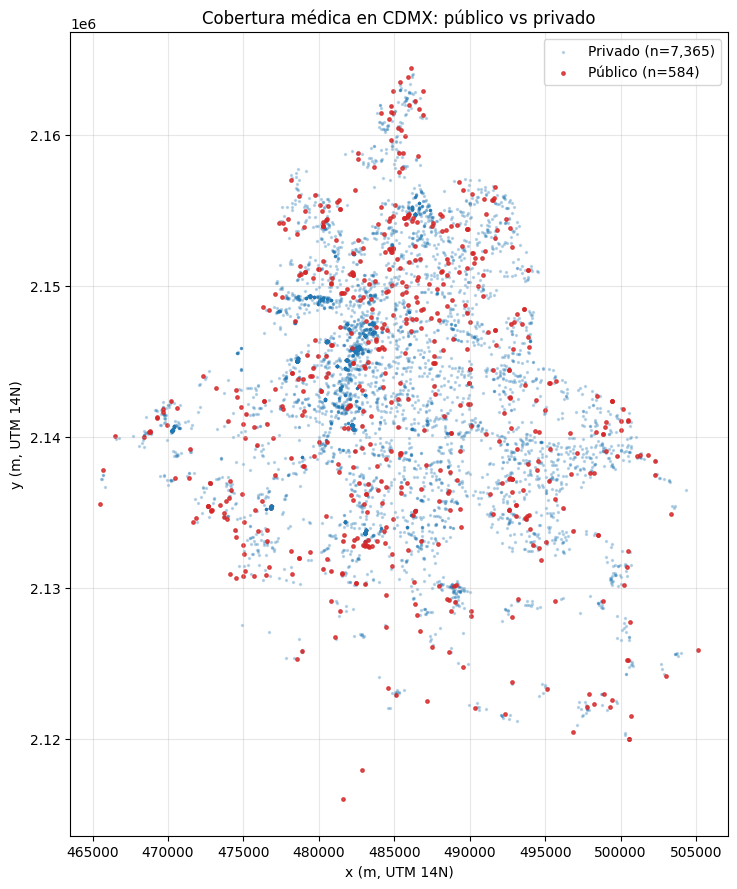

In [16]:
# Overlay: los dos sectores juntos para ver dónde se complementan / superponen
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(df_priv["x_m"], df_priv["y_m"], s=2, alpha=0.25, color="#1f77b4", label=f"Privado (n={len(df_priv):,})")
ax.scatter(df_pub["x_m"], df_pub["y_m"], s=6, alpha=0.8, color="#d62728", label=f"Público (n={len(df_pub):,})")

ax.set_xlabel("x (m, UTM 14N)")
ax.set_ylabel("y (m, UTM 14N)")
ax.set_title("Cobertura médica en CDMX: público vs privado")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Guardar las dos nubes de puntos

In [17]:
os.makedirs("../data/processed", exist_ok=True)

# Columnas finales que necesitamos para TDA
cols_finales = [
    "id", "nom_estab", "codigo_act", "nombre_act", "tipo_infra",
    "sector", "per_ocu", "municipio", "localidad",
    "latitud", "longitud", "x_m", "y_m", "fecha_alta"
]

df_pub[cols_finales].to_csv("../data/processed/salud_cdmx_publico.csv", index=False)
df_priv[cols_finales].to_csv("../data/processed/salud_cdmx_privado.csv", index=False)

print("Archivos guardados:")
print(f"  ../data/processed/salud_cdmx_publico.csv  ({len(df_pub):,} filas)")
print(f"  ../data/processed/salud_cdmx_privado.csv  ({len(df_priv):,} filas)")

Archivos guardados:
  ../data/processed/salud_cdmx_publico.csv  (584 filas)
  ../data/processed/salud_cdmx_privado.csv  (7,365 filas)


## Resumen y siguientes pasos

**Lo que tenemos al cerrar este notebook:**
- Dos nubes de puntos limpias con coordenadas en metros (UTM 14N).
- Sin duplicados exactos (jitter de ±5 m aplicado).
- Sin outliers geográficos.
- Etiquetas de tipo de infraestructura y sector para análisis estratificado posterior.

**Notebook 03 · Complejos simpliciales:**
- Construir Vietoris-Rips (o Alpha complex, más eficiente en 2D) para cada nube por separado.
- Calcular persistencia hasta H₁ (huecos).
- Generar los diagramas de persistencia comparativos.